# LTN Cross-Task Consistency — Presentation Analysis

Improved analysis notebook built for presenting preliminary findings to your supervisor.
Unlike `ltn_results_dashboard.ipynb` (which treats every result folder as an unordered
category and sorts bars alphabetically), this notebook **parses each config's actual
λ, detach_mode, and balance_losses settings** straight out of its folder name, so it can
build proper dose-response curves across λ, group configs by mechanism, and show
individual seeds as a scatter behind the mean — so noise is visible rather than hidden
behind an averaged bar.

**Run from the project root** (same folder as `aggregate_results.py`). All figures are
also saved to `figures/` as high-resolution PNGs, ready to drop straight into slides.

Sections:
1. Headline dose-response (both heads free) — gap vs λ, RRT accuracy vs λ
2. Bias trajectory & the overshoot — read the noise honestly
3. Detach-mode diagnostic — does the "who's cheating" asymmetry replicate?
4. The new headline — pushing the safe condition to a sweet spot at λ≈1.0
5. Slide-ready summary figure
6. Current seed coverage (data-quality check)

Because the parsing is done from the folder-naming convention (not a hardcoded list
of configs), this notebook needs **no edits** to pick up new λ values, new seeds, or a
second dataset (e.g. BPIC_17) once those results land — just re-run it.

In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import aggregate_results as ar

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

## Load data

Edit `LOG_NAME` below if you're analyzing a different dataset (e.g. once BPIC_17
generalization runs land).

In [2]:
LOG_NAME = "BPIC_19"
TRAINING_MODE = None  # only needed if a run directory has more than one results pickle

per_seed_df, grouped_df = ar.aggregate(LOG_NAME, TRAINING_MODE)
print(f"Found {len(per_seed_df)} runs across {per_seed_df['config'].nunique()} configuration(s).")

Found 29 runs across 15 configuration(s).


## Parse config names into real experiment parameters

`aggregate_results.py` groups by folder name, but a folder name like
`SUTRAN_DA_results_subset_0.15_ltn_0.5_detach_ttne` is just a string — it doesn't know
that this is "λ=0.5, safe condition" until we parse it. The regex below mirrors exactly
how `model_string` is built in `TRAIN_EVAL_EQUAL_WEIGHTING.py`, so it stays correct as
long as that naming convention doesn't change.

In [ ]:
def parse_config_name(name: str) -> dict:
    """Extracts lambda_ltn / detach_mode / balanced (+ its scales) / subset_fraction
    from a result-folder name, mirroring the `model_string` construction in
    TRAIN_EVAL_EQUAL_WEIGHTING.py. Works for any new config that follows the
    same naming convention -- e.g. future BPIC_17_DR runs need no changes here."""
    subset_match = re.search(r"_subset_([0-9.]+)", name)
    lambda_match = re.search(r"_ltn_([0-9.]+)", name)
    detach_match = re.search(r"_detach_(ttne|rrt)", name)
    # Newer balanced runs encode their scales, e.g. '_balanced_ttne1.0_rrt0.5'.
    # Older ones are bare '_balanced' -- those predate the balance_losses fix and
    # were inert (see quarantine_inert_balanced.py), so they should not be present.
    scales_match = re.search(r"_balanced_ttne([0-9.]+)_rrt([0-9.]+)", name)
    return {
        "subset_fraction": float(subset_match.group(1)) if subset_match else 1.0,
        "lambda_ltn": float(lambda_match.group(1)) if lambda_match else 0.0,
        "detach_mode": detach_match.group(1) if detach_match else "none",
        "balanced": "_balanced" in name,
        "scale_ttne": float(scales_match.group(1)) if scales_match else np.nan,
        "scale_rrt": float(scales_match.group(2)) if scales_match else np.nan,
    }


def classify_condition(row) -> str:
    """Groups each config into one of the mechanism conditions used throughout
    the analysis, independent of the exact lambda value."""
    if row["balanced"]:
        # Distinguish the two loss-reweighting controls: upweighting the RRT loss
        # ALONE is the control that rivals the safe condition (which feeds axiom
        # gradient to RRT only); upweighting both time losses tests a different
        # rival ("you rebalanced time vs activity").
        rrt_only = (row["scale_ttne"] == 1.0) and (row["scale_rrt"] != 1.0)
        if row["lambda_ltn"] == 0.0:
            return "ctrl_rrt_upweight" if rrt_only else "balanced_only"
        return "balanced_ltn"
    if row["lambda_ltn"] == 0.0:
        return "baseline"
    if row["detach_mode"] == "ttne":
        return "safe_only_rrt_moves"
    if row["detach_mode"] == "rrt":
        return "only_ttne_moves"
    return "both_free"


# IMPORTANT: reset the index BEFORE deriving `parsed` from it, so both frames
# share the same fresh 0..N-1 index -- otherwise pd.concat(axis=1) aligns by
# (mismatched) index label and silently pairs each config with the wrong
# parsed parameters. (Caught by visually spot-checking the first rendered
# charts against the source CSVs -- the notebook ran without error either way.)
per_seed_df = per_seed_df.reset_index(drop=True)
parsed = per_seed_df["config"].apply(parse_config_name).apply(pd.Series)
tidy_df = pd.concat([per_seed_df, parsed], axis=1)
tidy_df["condition"] = tidy_df.apply(classify_condition, axis=1)

# --- Unit normalisation: SECONDS -> MINUTES -------------------------------
# Everything in consistency_diagnostics.pkl is stored in seconds (the ttne/rrt
# labels unstandardize to seconds, cf. MAE_ttne_seconds in inference_procedure.py),
# whereas the headline "MAE RRT minutes" metric is already in minutes. Mixing
# the two silently makes bias/gap look ~60x larger than the accuracy numbers,
# so convert here, once, and plot everything in minutes.
#
# Sanity anchor: |mean signed error| can never exceed MAE. Baseline
# signed_bias_rrt_CB is ~624,442 vs MAE RRT ~23,999 min -- only consistent if
# the former is seconds (= ~10,407 min < 23,999 min).
SECONDS_METRIC_STEMS = [
    "mean_abs_gap", "mean_signed_gap",
    "signed_bias_rrt", "signed_bias_ttne_sum",
    "mae_ttne_sum", "mae_rrt",   # added later; absent until backfilled
]
# Matching by stem covers IB/CB *and* the '_raw' (unclamped) variants in one
# pass, so a newly added key can't silently stay in seconds while its sibling
# is in minutes.
SECONDS_METRICS = [
    c for c in tidy_df.columns
    if any(c == s or c.startswith(s + "_") for s in SECONDS_METRIC_STEMS)
]
for col in SECONDS_METRICS:
    tidy_df[col] = tidy_df[col] / 60.0
print(f"Converted {len(SECONDS_METRICS)} second-based metric column(s) to minutes.")

# Which of the newer metrics are actually populated (they only exist for runs
# processed by backfill_diagnostics.py, plus any run trained after the metric
# was added). Used to skip the head-to-head section gracefully.
NEW_MAE_COLS = ["mae_ttne_sum_CB", "mae_rrt_CB"]
HAS_MAE_METRICS = all(
    col in tidy_df.columns and tidy_df[col].notna().any() for col in NEW_MAE_COLS
)
HAS_CLAMP_COMPARISON = all(
    col in tidy_df.columns and tidy_df[col].notna().any()
    for col in ["signed_bias_ttne_sum_CB_raw", "frac_neg_ttne_step_preds"]
)
print("Σttne / RRT MAE metrics available:", HAS_MAE_METRICS)
print("clamped-vs-raw comparison available:", HAS_CLAMP_COMPARISON)

# Warn if any INERT pre-fix balanced folder is still in the analysis path: those
# runs were labelled '_balanced' but the rescaling never took effect, so they are
# duplicate baselines rather than controls.
inert_balanced = tidy_df.loc[tidy_df["balanced"] & tidy_df["scale_rrt"].isna(), "config"].unique()
if len(inert_balanced):
    print(f"\n!! WARNING: {len(inert_balanced)} pre-fix '_balanced' config(s) present "
          f"-- these are INERT duplicates, not controls:")
    for c in inert_balanced:
        print(f"     {c}")
    print("   Run `python quarantine_inert_balanced.py` to move them out of the way.")

CONDITION_COLORS = {
    "baseline": "#6b6b6b",
    "both_free": "#2a78d6",
    "safe_only_rrt_moves": "#1baf7a",
    "only_ttne_moves": "#e34948",
    "balanced_only": "#eda100",
    "balanced_ltn": "#4a3aa7",
    "ctrl_rrt_upweight": "#eb6834",
}
CONDITION_LABELS = {
    "baseline": "Baseline (λ=0)",
    "both_free": "Both heads free",
    "safe_only_rrt_moves": "Safe: only RRT moves",
    "only_ttne_moves": "Only Σttne moves",
    "balanced_only": "Loss-balanced (both)",
    "balanced_ltn": "Loss-balanced + LTN",
    "ctrl_rrt_upweight": "Control: RRT loss ×2",
}

tidy_df[["config", "seed", "lambda_ltn", "detach_mode", "balanced", "condition"]] \
    .sort_values(["condition", "lambda_ltn", "seed"]).reset_index(drop=True)

In [4]:
def dose_response(ax, df, conditions, lambda_values, metric_col, ylabel, color,
                   show_scatter=True, jitter_seed=0):
    """Line + errorbar dose-response across lambda_ltn, with individual seeds
    shown as a light scatter behind the mean -- makes noise visible instead of
    hiding it behind an averaged line."""
    subset = df[df["condition"].isin(conditions) & df["lambda_ltn"].isin(lambda_values)]
    grouped = subset.groupby("lambda_ltn")[metric_col].agg(["mean", "std", "count"]).reindex(lambda_values)
    x = np.arange(len(lambda_values))
    rng = np.random.default_rng(jitter_seed)
    if show_scatter:
        for i, lam in enumerate(lambda_values):
            pts = subset.loc[np.isclose(subset["lambda_ltn"], lam), metric_col]
            jitter = (rng.random(len(pts)) - 0.5) * 0.10
            ax.scatter(np.full(len(pts), i) + jitter, pts, color=color, alpha=0.35, s=26, zorder=2)
    ax.errorbar(x, grouped["mean"], yerr=grouped["std"].fillna(0), fmt="o-", color=color,
                capsize=4, linewidth=2.2, markersize=7, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels([str(l) for l in lambda_values])
    ax.set_xlabel("λ (lambda_ltn)")
    ax.set_ylabel(ylabel)
    for i, lam in enumerate(lambda_values):
        n = grouped["count"].iloc[i]
        if not np.isnan(n):
            ax.annotate(f"n={int(n)}", (i, grouped["mean"].iloc[i]), textcoords="offset points",
                        xytext=(0, 10), ha="center", fontsize=8, color="dimgray")
    return grouped


def grouped_bar(ax, df, spec, metric_col, ylabel, title=None):
    """Bar chart across a hand-picked list of (condition, lambda, label) triples --
    used for the detach-mode diagnostic, where the x-axis is 'which mechanism', not
    a continuous lambda sweep."""
    means, stds, ns, labels, colors = [], [], [], [], []
    for cond, lam, label in spec:
        rows = df[(df["condition"] == cond) & np.isclose(df["lambda_ltn"], lam)]
        means.append(rows[metric_col].mean())
        stds.append(rows[metric_col].std() if len(rows) > 1 else 0.0)
        ns.append(len(rows))
        labels.append(label)
        colors.append(CONDITION_COLORS[cond])
    x = np.arange(len(spec))
    ax.bar(x, means, yerr=stds, capsize=5, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    for i, n in enumerate(ns):
        offset = 10 if means[i] >= 0 else -18
        ax.annotate(f"n={n}", (i, means[i]), textcoords="offset points",
                    xytext=(0, offset), ha="center", fontsize=8, color="dimgray")

## 1. Headline dose-response (both heads free)

Both measures should trend the right direction as λ grows. Individual seeds are shown
as faint dots behind the mean line — watch how tight or scattered they are at each λ.

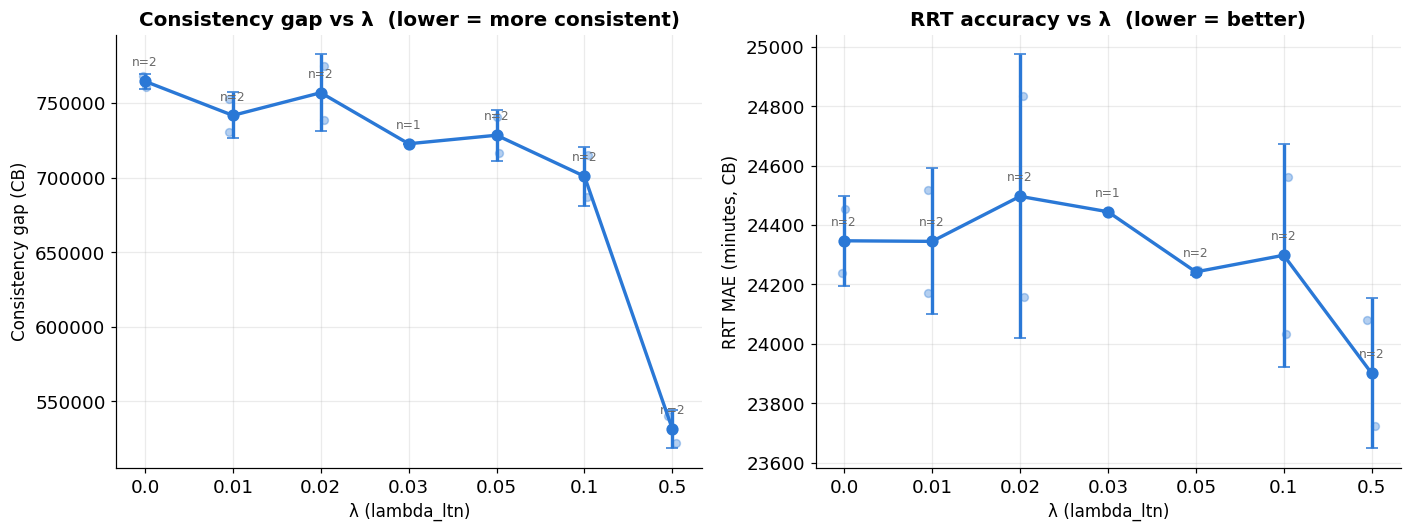

In [5]:
BOTH_FREE_LAMBDAS = sorted(tidy_df.loc[tidy_df["condition"].isin(["baseline", "both_free"]), "lambda_ltn"].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dose_response(axes[0], tidy_df, ["baseline", "both_free"], BOTH_FREE_LAMBDAS,
              "mean_abs_gap_CB", "Consistency gap (CB)", CONDITION_COLORS["both_free"])
axes[0].set_title("Consistency gap vs λ  (lower = more consistent)")

dose_response(axes[1], tidy_df, ["baseline", "both_free"], BOTH_FREE_LAMBDAS,
              "MAE RRT minutes", "RRT MAE (minutes, CB)", CONDITION_COLORS["both_free"])
axes[1].set_title("RRT accuracy vs λ  (lower = better)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_headline_dose_response.png", bbox_inches="tight")
plt.show()

**Reading this:** the gap should shrink substantially and fairly smoothly with λ. RRT
accuracy should stay roughly flat at low-to-moderate λ and only improve meaningfully
at the highest λ tested — if your data still shows that pattern, note how tight the
λ=0.5 scatter is compared to the middle λ values (that tightness is what makes it
trustworthy despite only 2 seeds).

## 2. Bias trajectory & the overshoot — read the noise honestly

At baseline, RRT over-predicts and Σttne under-predicts — correcting both toward zero
would shrink the gap "for free." Watch **where the scatter points agree on sign** versus
where they don't: that's the difference between a trend you can trust and one that's
just noise from 2 seeds.

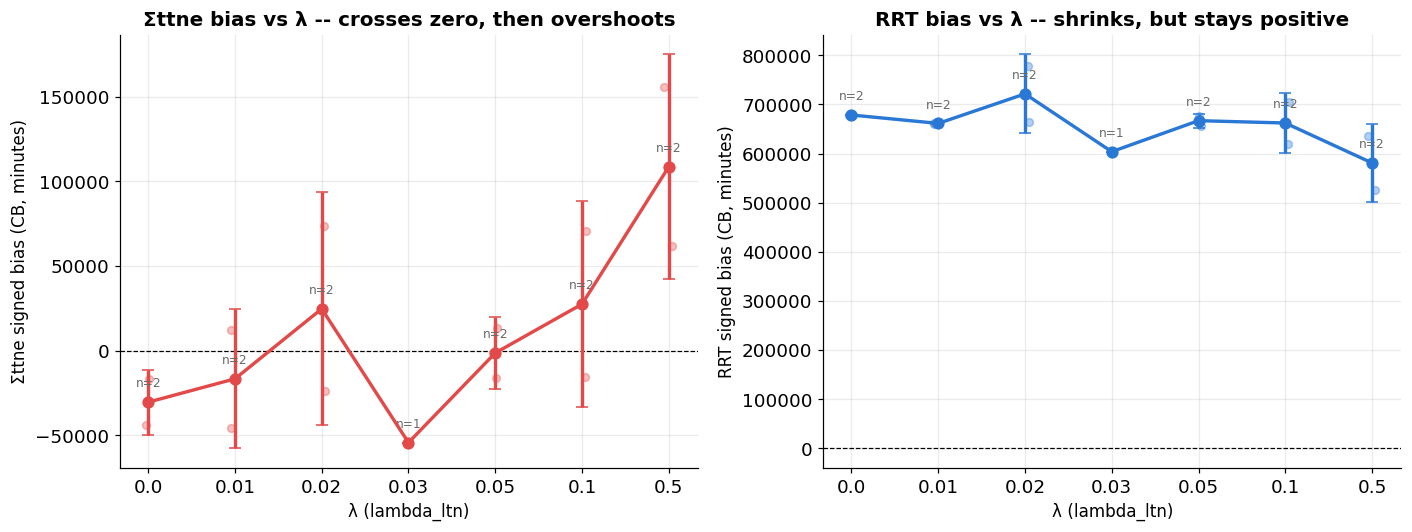

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dose_response(axes[0], tidy_df, ["baseline", "both_free"], BOTH_FREE_LAMBDAS,
              "signed_bias_ttne_sum_CB", "Σttne signed bias (CB, minutes)", "#e34948")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Σttne bias vs λ -- crosses zero, then overshoots")

dose_response(axes[1], tidy_df, ["baseline", "both_free"], BOTH_FREE_LAMBDAS,
              "signed_bias_rrt_CB", "RRT signed bias (CB, minutes)", "#2a78d6")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("RRT bias vs λ -- shrinks, but stays positive")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_bias_trajectory.png", bbox_inches="tight")
plt.show()

**Reading this:** at low λ (0.01–0.03), individual seeds for Σttne bias can disagree
even on sign — that region is noise-dominated with only 2 seeds and shouldn't be read
as a clean "crossing point." At higher λ (0.5+), seeds should agree on both sign and
rough magnitude — that's where the overshoot becomes a trend you can actually cite.

## 3. Detach-mode diagnostic — does the "who's cheating" asymmetry replicate?

Freezing one head's gradient from the axiom (`detach_mode`) isolates which head is
actually responding. With only 1 seed each, this can look like a clean asymmetry —
the point of re-running with more seeds is to check whether that's real or a coincidence
of which seed got sampled. **Overlapping error bars across conditions = it didn't replicate.**

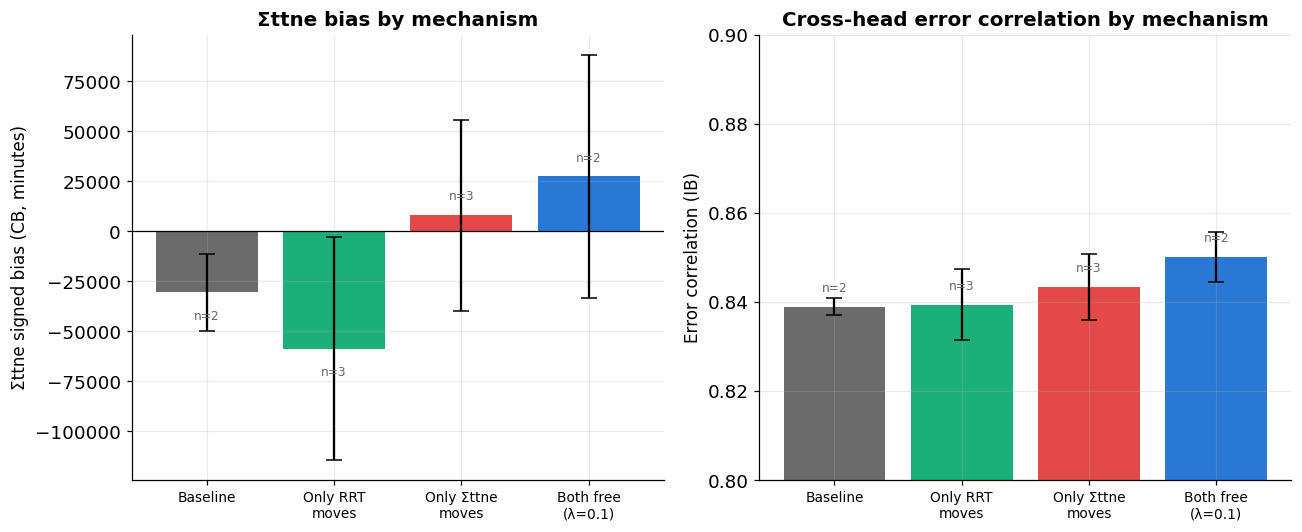

In [7]:
diag_spec = [
    ("baseline", 0.0, "Baseline"),
    ("safe_only_rrt_moves", 0.1, "Only RRT\nmoves"),
    ("only_ttne_moves", 0.1, "Only Σttne\nmoves"),
    ("both_free", 0.1, "Both free\n(λ=0.1)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
grouped_bar(axes[0], tidy_df, diag_spec, "signed_bias_ttne_sum_CB",
            "Σttne signed bias (CB, minutes)", "Σttne bias by mechanism")
grouped_bar(axes[1], tidy_df, diag_spec, "error_correlation_IB",
            "Error correlation (IB)", "Cross-head error correlation by mechanism")
axes[1].set_ylim(0.80, 0.90)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_detach_diagnostic.png", bbox_inches="tight")
plt.show()

**Reading this:** check whether the error bars for "Only RRT moves" and "Only Σttne
moves" overlap each other and the baseline bar. If they do (as they did once a 2nd and
3rd seed were added), the original single-seed "asymmetry" claim doesn't hold — that's
a legitimate methodological finding worth reporting (single-seed diagnostics can mislead),
not a failure of the study.

## 4. The new headline — pushing the safe condition to a sweet spot

Extending the safe condition (only RRT responds to the axiom) across a wider λ range
tests whether a higher dose of the *non-cheating-prone* mechanism can close more of the
gap without the drift seen in Section 2. Look for: does MAE bottom out somewhere in the
middle of the range rather than monotonically improving forever?

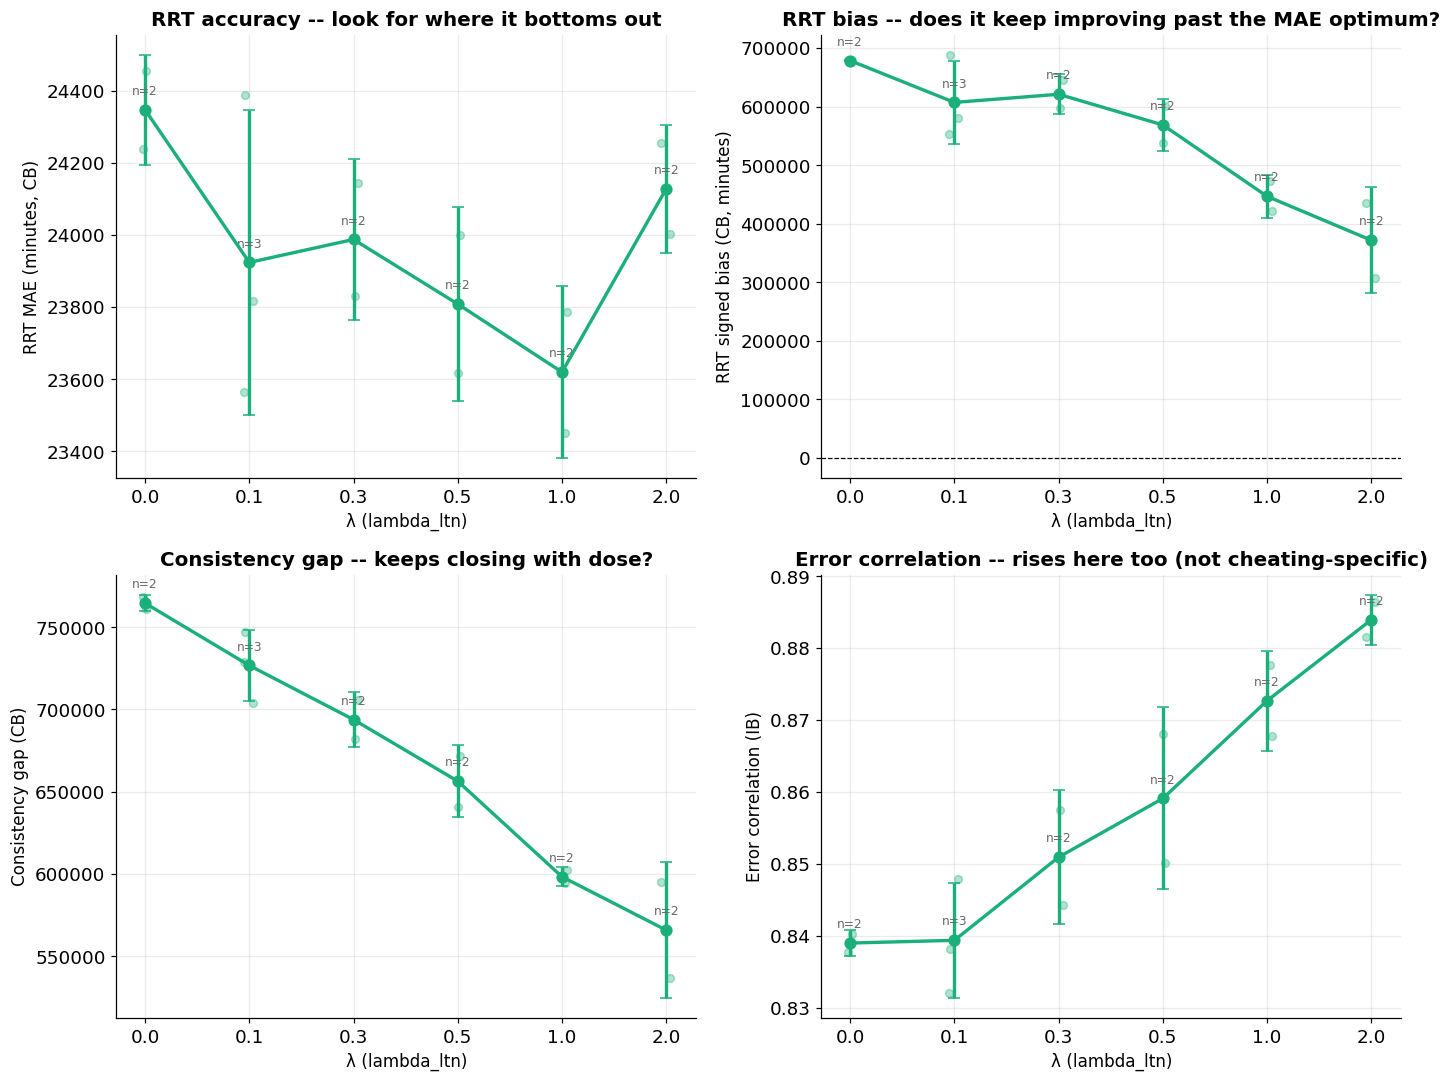

In [8]:
SAFE_LAMBDAS = sorted(tidy_df.loc[tidy_df["condition"].isin(["baseline", "safe_only_rrt_moves"]), "lambda_ltn"].unique())

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
dose_response(axes[0, 0], tidy_df, ["baseline", "safe_only_rrt_moves"], SAFE_LAMBDAS,
              "MAE RRT minutes", "RRT MAE (minutes, CB)", CONDITION_COLORS["safe_only_rrt_moves"])
axes[0, 0].set_title("RRT accuracy -- look for where it bottoms out")

dose_response(axes[0, 1], tidy_df, ["baseline", "safe_only_rrt_moves"], SAFE_LAMBDAS,
              "signed_bias_rrt_CB", "RRT signed bias (CB, minutes)", CONDITION_COLORS["safe_only_rrt_moves"])
axes[0, 1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 1].set_title("RRT bias -- does it keep improving past the MAE optimum?")

dose_response(axes[1, 0], tidy_df, ["baseline", "safe_only_rrt_moves"], SAFE_LAMBDAS,
              "mean_abs_gap_CB", "Consistency gap (CB)", CONDITION_COLORS["safe_only_rrt_moves"])
axes[1, 0].set_title("Consistency gap -- keeps closing with dose?")

dose_response(axes[1, 1], tidy_df, ["baseline", "safe_only_rrt_moves"], SAFE_LAMBDAS,
              "error_correlation_IB", "Error correlation (IB)", CONDITION_COLORS["safe_only_rrt_moves"])
axes[1, 1].set_title("Error correlation -- rises here too (not cheating-specific)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_safe_condition_sweep.png", bbox_inches="tight")
plt.show()

**Reading this:** if MAE has a clear minimum partway through the range (rather than at
the largest λ tested), that's a genuine sweet spot worth reporting as the headline
result — a real, replicated accuracy gain from a constrained, non-cheating-prone version
of the axiom. Note whether bias keeps improving past that MAE optimum (a sign that MAE
and bias aren't capturing quite the same thing at high λ), and whether correlation still
climbs even here — a reminder that rising correlation alone isn't sufficient evidence of
cheating, since this condition shows genuine gains too.

## 5. Slide-ready summary figure

A useful 4 panel figure worth saving.
Saved as `figures/00_headline_summary.png` at high resolution — the "00" prefix keeps
it first alphabetically in the folder for quick access.

## 5. Head-to-head: which route to "total remaining time" is more accurate?

Σttne and RRT are two different estimates of **the same quantity** — how much time is
left in the case. RRT predicts it directly; Σttne gets there by summing the predicted
per-step gaps across the suffix. So their absolute errors are directly comparable, and
this is the sharpest accuracy question the axiom can be asked:

> Does enforcing consistency make the *worse* route better, or just drag both toward
> each other?

This is also why MAE matters on top of signed bias: a head whose over- and
under-predictions cancel out can show near-zero *bias* while still being badly wrong
case-by-case. MAE can't be gamed that way.

*Requires the newer `mae_ttne_sum_*` / `mae_rrt_*` metrics — run
`python backfill_diagnostics.py` to populate them for existing runs. This section
skips itself cleanly if they aren't available yet.*

In [ ]:
def head_to_head(ax, df, conditions, lambda_values, title):
    """Plots MAE of both routes to total remaining time on ONE axis (same
    quantity, same units -- so a shared scale is correct here, not a dual axis)."""
    subset = df[df["condition"].isin(conditions) & df["lambda_ltn"].isin(lambda_values)]
    x = np.arange(len(lambda_values))
    for col, label, color in [
        ("mae_rrt_CB", "RRT head (direct)", "#2a78d6"),
        ("mae_ttne_sum_CB", "Σttne (summed suffix)", "#eb6834"),
    ]:
        g = subset.groupby("lambda_ltn")[col].agg(["mean", "std"]).reindex(lambda_values)
        ax.errorbar(x, g["mean"], yerr=g["std"].fillna(0), fmt="o-", color=color,
                    capsize=4, linewidth=2.2, markersize=7, label=label)
    ax.set_xticks(x)
    ax.set_xticklabels([str(l) for l in lambda_values])
    ax.set_xlabel("λ (lambda_ltn)")
    ax.set_ylabel("MAE of total remaining time (minutes, CB)")
    ax.set_title(title)
    ax.legend()


if HAS_MAE_METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    head_to_head(axes[0], tidy_df, ["baseline", "both_free"], BOTH_FREE_LAMBDAS,
                 "Both heads free")
    head_to_head(axes[1], tidy_df, ["baseline", "safe_only_rrt_moves"], SAFE_LAMBDAS,
                 "Safe condition (only RRT moves)")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/05_head_to_head_mae.png", bbox_inches="tight")
    plt.show()

    # Compact table of the same comparison, including the ratio between routes.
    rows = []
    for cond, lams in [("both_free", BOTH_FREE_LAMBDAS), ("safe_only_rrt_moves", SAFE_LAMBDAS)]:
        sub = tidy_df[tidy_df["condition"].isin(["baseline", cond]) & tidy_df["lambda_ltn"].isin(lams)]
        for lam in lams:
            r = sub[np.isclose(sub["lambda_ltn"], lam)]
            if len(r) == 0:
                continue
            rrt, ttne = r["mae_rrt_CB"].mean(), r["mae_ttne_sum_CB"].mean()
            rows.append({
                "condition": CONDITION_LABELS["baseline" if lam == 0.0 else cond],
                "λ": lam,
                "n": len(r),
                "MAE RRT (min)": round(rrt),
                "MAE Σttne (min)": round(ttne),
                "Σttne / RRT": round(ttne / rrt, 3) if rrt else np.nan,
            })
    display(pd.DataFrame(rows).drop_duplicates(subset=["condition", "λ"]).reset_index(drop=True))
else:
    print("Skipped -- mae_ttne_sum_* / mae_rrt_* not present in the loaded results yet.")
    print("Run `python backfill_diagnostics.py` (≈8h GPU for all 29 runs, no retraining),")
    print("then re-run this notebook to populate this section.")

### 5b. The same head-to-head, but in SIGNED BIAS

Section 5 asks *how large* each route's error is. This asks *which direction* it
leans — the diagnostic that separates "both heads converged on the truth" from
"both heads drifted toward each other" (the cheating signature).

At baseline the two lean opposite ways: **RRT over-predicts** (bias ≈ +10,400 min)
while **Σttne under-predicts** (≈ −1,000 min). Correcting either toward zero also
shrinks the gap, so a genuine improvement and a cosmetic one look the same in the
gap alone — only the signed biases tell them apart.

**On per-step TTNE bias:** it is not separately recorded, and under the natural
definition it would carry no additional information. Per-step bias is
`total signed error ÷ total steps`; summed bias is `total signed error ÷ number of
instances`. Same numerator, different constant divisor — so per-step bias is exactly
Σttne bias ÷ mean suffix length (3.60), i.e. the same curve rescaled. The value is
printed below for reference rather than plotted as a redundant third line.

A genuinely *different* per-step quantity does exist — the per-instance mean of
per-step biases, which weights short cases more heavily than long ones — but that
needs a new metric in `inference_procedure.py` plus a re-inference backfill. Say the
word if it's worth the ~8h.

In [ ]:
MEAN_SUFFIX_LEN = 3.60   # test set, from the label-identity check (250,545 instances)

BIAS_SERIES = [
    ("signed_bias_rrt_CB",      "RRT head (direct)",     "#2a78d6"),
    ("signed_bias_ttne_sum_CB", "Σttne (summed suffix)", "#eb6834"),
]


def bias_head_to_head(ax, df, conditions, lambda_values, title):
    """Signed bias of both routes on ONE axis -- same quantity, same units, so a
    shared scale is correct (never a dual axis)."""
    subset = df[df["condition"].isin(conditions) & df["lambda_ltn"].isin(lambda_values)]
    x = np.arange(len(lambda_values))
    for col, label, colour in BIAS_SERIES:
        g = subset.groupby("lambda_ltn")[col].agg(["mean", "std"]).reindex(lambda_values)
        ax.errorbar(x, g["mean"], yerr=g["std"].fillna(0), fmt="o-", color=colour,
                    capsize=4, linewidth=2.2, markersize=7, label=label, zorder=3)
    ax.axhline(0, color="black", linewidth=1.2, linestyle="--", zorder=1)
    ax.annotate("unbiased", (0.985, 0), xycoords=("axes fraction", "data"),
                textcoords="offset points", xytext=(0, 5), ha="right",
                fontsize=9, color="dimgray")
    ax.set_xticks(x)
    ax.set_xticklabels([str(l) for l in lambda_values])
    ax.set_xlabel("λ (lambda_ltn)")
    ax.set_ylabel("Signed bias (minutes, CB)\n↑ over-predicts   ↓ under-predicts")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
bias_head_to_head(axes[0], tidy_df, ["baseline", "both_free"], BOTH_FREE_LAMBDAS,
                  "Both heads free")
bias_head_to_head(axes[1], tidy_df, ["baseline", "safe_only_rrt_moves"], SAFE_LAMBDAS,
                  "Safe condition (only RRT moves)")
fig.suptitle("Signed bias of each route to total remaining time  "
             "(distance from the dashed line = distance from truth)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/10_head_to_head_bias.png", bbox_inches="tight", dpi=250)
plt.show()

# Table: both measured biases, plus the derived per-step figure.
rows = []
for cond, lams, label in [("both_free", BOTH_FREE_LAMBDAS, "Both free"),
                          ("safe_only_rrt_moves", SAFE_LAMBDAS, "Safe")]:
    sub = tidy_df[tidy_df["condition"].isin(["baseline", cond]) & tidy_df["lambda_ltn"].isin(lams)]
    for lam in lams:
        r = sub[np.isclose(sub["lambda_ltn"], lam)]
        if len(r) == 0:
            continue
        b_rrt = r["signed_bias_rrt_CB"].mean()
        b_sum = r["signed_bias_ttne_sum_CB"].mean()
        rows.append({
            "condition": "Baseline" if lam == 0.0 else label,
            "λ": lam, "n": len(r),
            "RRT bias (min)": round(b_rrt),
            "Σttne bias (min)": round(b_sum),
            "→ per-step TTNE bias (min)": round(b_sum / MEAN_SUFFIX_LEN, 1),
            "|RRT| + |Σttne|": round(abs(b_rrt) + abs(b_sum)),
        })
bias_tbl = pd.DataFrame(rows).drop_duplicates(subset=["condition", "λ"]).reset_index(drop=True)
display(bias_tbl)
print("'per-step TTNE bias' is DERIVED as Σttne bias / mean suffix length (3.60) --")
print("it is the same quantity rescaled, not an independent measurement.")
print("'|RRT| + |Σttne|' is total distance from truth across both heads: if the axiom")
print("were merely dragging the heads together, this would stay flat while the gap shrank.")

## 6. Secondary observation: Σttne vs the RRT head (NOT the evaluation criterion)

**This section is an aside, not a headline.** The primary accuracy criterion in this
study is each head's **own** metric — Section 7 — because that is how a multi-task
model is actually used:

> To predict remaining time in deployment you call the **RRT head**: one forward pass.
> You would not run full autoregressive suffix decoding and sum the per-step
> predictions. The RRT head exists precisely to be that interface, and
> `MAE RRT minutes` is the metric convention the SuTraN+ paper itself reports.

What follows is still worth knowing, because it says something surprising about the
*model* (and is a candidate thesis extension in its own right):

**Summing the predicted suffix is ~24% more accurate at estimating total remaining
time than the dedicated RRT head** (≈18,615 vs ≈23,999 min at baseline, in 29/29 runs
measured). Plausible mechanism: the ttne head receives one supervision signal per
suffix step versus one per case for RRT, and summing ~3.6 partially-independent step
errors grows error like √k rather than k.

Two cautions on reading it:

- It does **not** mean the ttne head is better *per step* — errors cancel inside the
  sum before the absolute value is taken. Section 7's per-step metric is the one that
  answers that.
- Obtaining it costs a full autoregressive decode, so it is not a free swap for the
  RRT head in production.

Treat it as a finding about SuTraN+'s architecture, independent of LTN — worth a
sentence in the presentation and possibly a chapter in the thesis, but not the
yardstick the axiom should be judged by.

In [ ]:
if HAS_MAE_METRICS:
    # Per RUN, the error you'd actually incur by picking the better route.
    # Taken per-run (not per-mean) so the seed-to-seed spread is honest.
    tidy_df["mae_best_available_CB"] = tidy_df[["mae_ttne_sum_CB", "mae_rrt_CB"]].min(axis=1)
    tidy_df["better_route"] = np.where(
        tidy_df["mae_ttne_sum_CB"] <= tidy_df["mae_rrt_CB"], "Σttne", "RRT")

    baseline_best = tidy_df.loc[tidy_df["condition"] == "baseline", "mae_best_available_CB"].mean()
    print(f"Baseline best-available MAE: {baseline_best:,.0f} min")
    print("Better route per run:",
          tidy_df["better_route"].value_counts().to_dict())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (cond, lams, title) in zip(axes, [
        ("both_free", BOTH_FREE_LAMBDAS, "Both heads free"),
        ("safe_only_rrt_moves", SAFE_LAMBDAS, "Safe condition (only RRT moves)"),
    ]):
        dose_response(ax, tidy_df, ["baseline", cond], lams,
                      "mae_best_available_CB", "Best-available MAE (minutes, CB)",
                      CONDITION_COLORS[cond])
        ax.axhline(baseline_best, color="black", linewidth=1, linestyle="--")
        ax.annotate("baseline", (0.02, baseline_best), xycoords=("axes fraction", "data"),
                    textcoords="offset points", xytext=(0, 4), fontsize=9, color="dimgray")
        ax.set_title(f"{title} — lower is better")

    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/06_best_available_estimator.png", bbox_inches="tight")
    plt.show()

    # Does ANY config beat the baseline's best-available error?
    summary = (tidy_df.groupby(["condition", "lambda_ltn"])["mae_best_available_CB"]
               .agg(["mean", "std", "count"]).reset_index())
    summary["vs_baseline_%"] = 100 * (summary["mean"] - baseline_best) / baseline_best
    summary = summary.sort_values("mean")
    print("\nRanked by best-available MAE (negative % = better than baseline):")
    display(summary.head(10).round(2))

    winners = summary[(summary["vs_baseline_%"] < 0) & (summary["condition"] != "baseline")]
    if len(winners) == 0:
        print("\n=> NO configuration improves the best-available estimate.")
        print("   The accuracy claim is a null result; lead with consistency instead.")
    else:
        print(f"\n=> {len(winners)} config(s) beat baseline on best-available MAE "
              f"-- check whether the margin exceeds seed noise before claiming it.")
else:
    print("Skipped -- run `python backfill_diagnostics.py` first.")

## 7. Do-no-harm audit — each task at its OWN metric

Sections 5 and 6 ask which route best predicts *total remaining time*. That is not
what two of the three heads are trained for. This section asks the separate and
arguably more important question:

> Does the consistency axiom degrade any task at the job it was actually meant to do?

The three native metrics:

| Task | Metric | Note |
|---|---|---|
| Timestamp suffix | **MAE TTNE minutes** | error on each *next-event gap* — per-step, not summed |
| Activity suffix | **DL sim** | normalized Damerau-Levenshtein similarity (higher is better) |
| Remaining runtime | **MAE RRT minutes** | direct total-time prediction |

`MAE TTNE minutes` is deliberately *not* the same as `mae_ttne_sum` from Section 5.
The former scores per-step gap prediction; the latter sums the suffix to estimate a
total. A head can improve at one while worsening at the other — summing lets
per-step errors cancel, so a model could get sloppier step-by-step yet still produce
a decent total (or vice versa). Tracking both is what separates "the axiom helped"
from "the axiom moved error around."

Everything is plotted as **% worse than baseline, oriented so lower is always
better** (DL sim is sign-flipped, since higher similarity is better). The dashed
line at zero is baseline; anything meaningfully above it is a task the axiom hurt.

In [ ]:
# (metric column, display label, higher_is_better)
NATIVE_TASKS = [
    ("MAE TTNE minutes", "Timestamp suffix (per-step TTNE MAE)", False),
    ("DL sim",           "Activity suffix (DL similarity)",      True),
    ("MAE RRT minutes",  "Remaining runtime (RRT MAE)",          False),
]
missing = [m for m, _, _ in NATIVE_TASKS if m not in tidy_df.columns]

if missing:
    print(f"Missing native-task column(s): {missing}")
    print("Add them to METRIC_KEYS in aggregate_results.py, then re-run this notebook.")
else:
    base_rows = tidy_df[tidy_df["condition"] == "baseline"]
    baselines = {m: base_rows[m].mean() for m, _, _ in NATIVE_TASKS}
    # Baseline seed spread, as the yardstick for "is a change meaningful?"
    base_noise = {m: 100 * base_rows[m].std() / abs(baselines[m]) for m, _, _ in NATIVE_TASKS}
    print("Baseline (n={}) and its seed noise:".format(len(base_rows)))
    for m, label, _ in NATIVE_TASKS:
        print(f"  {label:<40} {baselines[m]:>12,.4f}   (seed sd = {base_noise[m]:.2f}%)")

    def pct_worse(series, metric, higher_is_better):
        """% worse than baseline, oriented so LOWER IS ALWAYS BETTER."""
        delta = 100 * (series - baselines[metric]) / abs(baselines[metric])
        return -delta if higher_is_better else delta

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    for ax, (cond, lams, title) in zip(axes, [
        ("both_free", BOTH_FREE_LAMBDAS, "Both heads free"),
        ("safe_only_rrt_moves", SAFE_LAMBDAS, "Safe condition (only RRT moves)"),
    ]):
        sub = tidy_df[tidy_df["condition"].isin(["baseline", cond])
                      & tidy_df["lambda_ltn"].isin(lams)]
        x = np.arange(len(lams))
        for (metric, label, hib), colour in zip(NATIVE_TASKS, ["#eb6834", "#4a3aa7", "#2a78d6"]):
            g = sub.groupby("lambda_ltn")[metric].mean().reindex(lams)
            ax.plot(x, pct_worse(g, metric, hib), "o-", color=colour,
                    linewidth=2.2, markersize=7, label=label)
        # Shade the band where a change is indistinguishable from baseline noise.
        worst_noise = max(base_noise.values())
        ax.axhspan(-worst_noise, worst_noise, color="gray", alpha=0.13, zorder=0)
        ax.axhline(0, color="black", linewidth=1, linestyle="--")
        ax.set_xticks(x); ax.set_xticklabels([str(l) for l in lams])
        ax.set_xlabel("λ (lambda_ltn)")
        ax.set_title(title)
    axes[0].set_ylabel("% worse than baseline  (lower = better)")
    axes[0].legend(fontsize=9)
    fig.suptitle("Do-no-harm audit: each task at its own metric "
                 "(shaded band = baseline seed noise)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/07_do_no_harm_audit.png", bbox_inches="tight")
    plt.show()

    # Table: flag any task/config that is worse than baseline by more than noise.
    rows = []
    for (cond, lam), grp in tidy_df.groupby(["condition", "lambda_ltn"]):
        if cond == "baseline":
            continue
        row = {"condition": CONDITION_LABELS.get(cond, cond), "λ": lam, "n": len(grp)}
        harmed = []
        for metric, label, hib in NATIVE_TASKS:
            w = pct_worse(grp[metric].mean(), metric, hib)
            row[label.split(" (")[0]] = round(w, 2)
            if w > base_noise[metric]:
                harmed.append(label.split(" (")[0])
        row["harmed beyond noise"] = ", ".join(harmed) if harmed else "-"
        rows.append(row)
    audit = pd.DataFrame(rows).sort_values(["condition", "λ"]).reset_index(drop=True)
    print("\n% worse than baseline per task (lower = better; > baseline seed noise = flagged):")
    display(audit)

## 8. The control: is it the logic, or just loss weighting?  ← headline slide

The obvious sceptical reading of Section 4 is: *"you fed extra gradient to the RRT
head, so of course it improved — nothing to do with logic."* The safe condition
(`detach_mode="ttne"`) routes axiom gradient to RRT **only**, so the matched control
is to simply **upweight the RRT loss** and change nothing else:

```
--balance_losses --scale_ttne 1.0 --scale_rrt 0.5     # RRT loss ×2, ttne untouched
```

The two mechanisms differ in *what they pull RRT toward*:

| | pulls RRT toward | |
|---|---|---|
| RRT loss ×2 (control) | its own **labels**, harder | a stronger version of what training already does |
| LTN axiom (λ) | the **Σttne prediction** | a target the RRT head has no other access to |

If the control reproduces the effect, the axiom is redundant. If it doesn't, the
logical constraint is contributing something training cannot reach on its own.

*This is the single most important comparison in the study — it's what separates
"we reweighted a loss" from "the constraint does real work."*

In [ ]:
CTRL = "ctrl_rrt_upweight"
BEST_LAMBDA = 1.0   # the operating point the control is compared against

have_ctrl = (tidy_df["condition"] == CTRL).any()
if not have_ctrl:
    print("Control runs not found -- run `python run_phase3.py` (tier 2).")
else:
    from scipy import stats as _st

    def grab(cond, lam=None):
        m = tidy_df["condition"] == cond
        if lam is not None:
            m &= np.isclose(tidy_df["lambda_ltn"], lam)
        return tidy_df[m]

    groups = [
        ("Baseline", grab("baseline"), CONDITION_COLORS["baseline"]),
        ("Control:\nRRT loss ×2", grab(CTRL), CONDITION_COLORS[CTRL]),
        (f"LTN axiom\n(λ={BEST_LAMBDA})", grab("safe_only_rrt_moves", BEST_LAMBDA),
         CONDITION_COLORS["safe_only_rrt_moves"]),
    ]

    # NATIVE task metrics + the consistency gap. Each head judged on the job it is
    # actually deployed to do -- remaining time comes from the RRT head, not from
    # summing the ttne suffix (see Section 6).
    PANELS = [
        ("mean_abs_gap_CB",   "Consistency gap (min, CB)",      "the claim"),
        ("MAE RRT minutes",   "RRT MAE (min, CB)",              "the claim"),
        ("MAE TTNE minutes",  "TTNE per-step MAE (min, CB)",    "do no harm"),
        ("DL sim",            "Activity suffix DL-sim",         "do no harm"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(17, 4.8))
    for ax, (col, label, role) in zip(axes, PANELS):
        means = [g[col].mean() for _, g, _ in groups]
        stds = [g[col].std() if len(g) > 1 else 0.0 for _, g, _ in groups]
        ns = [len(g) for _, g, _ in groups]
        colours = [c for _, _, c in groups]
        x = np.arange(len(groups))
        ax.bar(x, means, yerr=stds, capsize=5, color=colours)
        ax.set_xticks(x)
        ax.set_xticklabels([n for n, _, _ in groups], fontsize=9)
        ax.set_title(f"{label}\n({role})", fontsize=10.5)

        lo = min(m - s for m, s in zip(means, stds))
        hi = max(m + s for m, s in zip(means, stds))
        pad = (hi - lo) * 0.45 + 1e-9
        y0, y1 = (max(0, lo - pad), hi + pad) if col != "DL sim" else (lo - pad, hi + pad)
        ax.set_ylim(y0, y1)

        for i in (1, 2):
            pct = 100 * (means[i] - means[0]) / abs(means[0])
            _, pv = _st.ttest_ind(groups[i][1][col], groups[0][1][col], equal_var=False)
            mark = "*" if pv < 0.05 else ""
            ax.annotate(f"{pct:+.1f}%{mark}", (i, means[i] + stds[i]),
                        textcoords="offset points", xytext=(0, 7), ha="center",
                        fontsize=11, fontweight="bold")
        for i, n in enumerate(ns):
            ax.annotate(f"n={n}", (i, y0), textcoords="offset points",
                        xytext=(0, 6), ha="center", fontsize=8, color="white")
    fig.suptitle("Native task metrics: does the LTN axiom beat simply upweighting the "
                 "RRT loss?   (% vs baseline;  * = p<0.05)",
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/08_control_comparison.png", bbox_inches="tight", dpi=250)
    plt.show()

    base = groups[0][1]
    rows = []
    for name, g, _ in groups:
        row = {"condition": name.replace("\n", " "), "n": len(g)}
        for col, label, _role in PANELS:
            short = label.split(" (")[0]
            row[short] = round(g[col].mean(), 4 if col == "DL sim" else 0)
            if name != "Baseline" and len(g) > 1:
                pct = 100 * (g[col].mean() - base[col].mean()) / abs(base[col].mean())
                _, pv = _st.ttest_ind(g[col], base[col], equal_var=False)
                row[short + " Δ%"] = f"{pct:+.2f} (p={pv:.3f})"
        rows.append(row)
    display(pd.DataFrame(rows).set_index("condition").T)
    print("Note: for DL sim a POSITIVE Δ% is better (higher similarity); for the three "
          "MAE/gap columns a NEGATIVE Δ% is better.")

In [ ]:
# --- Dose-response on NATIVE metrics: where is the operating point? -------
# y-axis is the RRT head's OWN metric, because that is the head you call in
# deployment to get a remaining-time estimate (see Section 6). Points BELOW the
# zero line are a win on accuracy AND (moving right) on consistency.
from scipy import stats as _st

base_rows = tidy_df[tidy_df["condition"] == "baseline"]
b_gap = base_rows["mean_abs_gap_CB"].mean()
b_rrt = base_rows["MAE RRT minutes"].mean()
b_ttne = base_rows["MAE TTNE minutes"].mean()
noise_rrt = 100 * base_rows["MAE RRT minutes"].std() / b_rrt
noise_ttne = 100 * base_rows["MAE TTNE minutes"].std() / b_ttne

safe = tidy_df[tidy_df["condition"] == "safe_only_rrt_moves"]
lams = sorted(safe["lambda_ltn"].unique())

pts = []
for lam in lams:
    g = safe[np.isclose(safe["lambda_ltn"], lam)]
    _, p_rrt = _st.ttest_ind(g["MAE RRT minutes"], base_rows["MAE RRT minutes"],
                             equal_var=False) if len(g) > 1 else (np.nan, np.nan)
    _, p_gap = _st.ttest_ind(g["mean_abs_gap_CB"], base_rows["mean_abs_gap_CB"],
                             equal_var=False) if len(g) > 1 else (np.nan, np.nan)
    pts.append({
        "λ": lam, "n": len(g),
        "gap_red_%": 100 * (b_gap - g["mean_abs_gap_CB"].mean()) / b_gap,
        "rrt_Δ%": 100 * (g["MAE RRT minutes"].mean() - b_rrt) / b_rrt,
        "ttne_step_Δ%": 100 * (g["MAE TTNE minutes"].mean() - b_ttne) / b_ttne,
        "p_rrt": p_rrt, "p_gap": p_gap,
    })
frontier = pd.DataFrame(pts)

fig, ax = plt.subplots(figsize=(9, 6))
ax.axhspan(-noise_rrt, noise_rrt, color="gray", alpha=0.12, zorder=0)
ax.annotate(f"within baseline seed noise (±{noise_rrt:.2f}%)",
            (0.02, noise_rrt), xycoords=("axes fraction", "data"),
            textcoords="offset points", xytext=(0, 4), fontsize=9, color="dimgray")
ax.axhline(0, color="black", linewidth=1, linestyle="--")

ax.plot(frontier["gap_red_%"], frontier["rrt_Δ%"], "-", color="#1baf7a",
        linewidth=2.2, zorder=2)
for _, r in frontier.iterrows():
    sig = (not np.isnan(r["p_rrt"])) and r["p_rrt"] < 0.05
    ax.scatter(r["gap_red_%"], r["rrt_Δ%"], s=190 if sig else 110,
               color="#1baf7a", edgecolor="white", linewidth=2,
               marker="*" if sig else "o", zorder=3)
    ax.annotate(f"λ={r['λ']:g} (n={int(r['n'])})",
                (r["gap_red_%"], r["rrt_Δ%"]), textcoords="offset points",
                xytext=(9, 7), fontsize=10, fontweight="bold")
ax.scatter([0], [0], s=140, color=CONDITION_COLORS["baseline"],
           edgecolor="white", linewidth=2, zorder=3)
ax.annotate("baseline", (0, 0), textcoords="offset points", xytext=(8, -15), fontsize=10)

ax.set_xlabel("Consistency gap reduction vs baseline (%)   →  better")
ax.set_ylabel("RRT MAE change vs baseline (%)   ↓ better")
ax.set_title("Operating point on native metrics:\nconsistency gained vs the RRT head's "
             "own accuracy  (★ = p<0.05 on RRT MAE)", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/09_tradeoff_frontier.png", bbox_inches="tight", dpi=250)
plt.show()

show = frontier.copy()
show["RRT sig?"] = np.where(show["p_rrt"] < 0.05, "yes", "no")
show["ttne harmed?"] = np.where(show["ttne_step_Δ%"] > noise_ttne, "beyond noise", "no")
print(f"Baseline: RRT MAE {b_rrt:,.0f} min (seed sd {noise_rrt:.2f}%) | "
      f"TTNE/step {b_ttne:,.0f} min (seed sd {noise_ttne:.2f}%)")
display(show.round(3))

best = frontier[(frontier["p_rrt"] < 0.05)].sort_values("rrt_Δ%").head(1)
if len(best):
    r = best.iloc[0]
    print(f"=> Best operating point on native metrics: λ={r['λ']:g} -- "
          f"RRT MAE {r['rrt_Δ%']:+.2f}% (p={r['p_rrt']:.4f}) with "
          f"{r['gap_red_%']:.1f}% less inconsistency, and no task harmed beyond noise.")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

dose_response(axes[0, 0], tidy_df, ["baseline", "both_free"], BOTH_FREE_LAMBDAS,
              "mean_abs_gap_CB", "Consistency gap (CB)", CONDITION_COLORS["both_free"], show_scatter=False)
axes[0, 0].set_title("Consistency gap vs λ (both free)")

dose_response(axes[0, 1], tidy_df, ["baseline", "safe_only_rrt_moves"], SAFE_LAMBDAS,
              "MAE RRT minutes", "RRT MAE (minutes, CB)", CONDITION_COLORS["safe_only_rrt_moves"], show_scatter=False)
axes[0, 1].set_title("RRT accuracy vs λ (safe condition)")

grouped_bar(axes[1, 0], tidy_df, diag_spec, "error_correlation_IB",
            "Error correlation (IB)", "Detach diagnostic")
axes[1, 0].set_ylim(0.80, 0.90)

dose_response(axes[1, 1], tidy_df, ["baseline", "safe_only_rrt_moves"], SAFE_LAMBDAS,
              "signed_bias_rrt_CB", "RRT signed bias (CB, minutes)", CONDITION_COLORS["safe_only_rrt_moves"], show_scatter=False)
axes[1, 1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1, 1].set_title("RRT bias vs λ (safe condition)")

fig.suptitle("LTN Cross-Task Consistency -- Preliminary Findings", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_headline_summary.png", bbox_inches="tight", dpi=250)
plt.show()

print(f"All figures saved to ./{FIGURES_DIR}/ -- 00_headline_summary.png is sized for a single slide.")

## 6. Current seed coverage (data-quality check)

A quick pivot showing exactly which seeds have run for each condition/λ combination —
useful before trusting any panel above, and useful for planning what to run next.

In [ ]:
coverage = (
    tidy_df.groupby(["condition", "lambda_ltn"])["seed"]
    .apply(lambda s: sorted(s.tolist()))
    .reset_index()
)
coverage["n_seeds"] = coverage["seed"].apply(len)
coverage["condition_label"] = coverage["condition"].map(CONDITION_LABELS)
coverage[["condition_label", "lambda_ltn", "n_seeds", "seed"]] \
    .sort_values(["condition_label", "lambda_ltn"]).reset_index(drop=True)

## 9. BPIC_17_DR — every metric, and the question of which head we constrained

`LOG_NAME` at the top is `BPIC_19`; this section loads **BPIC_17_DR into its own frame**, so
nothing above is disturbed and both logs can be read side by side.

n=2 (seeds {3, 17}), so nothing here is powered and no p-values are shown. Per-seed points are
drawn as paired lines: with two seeds the only honest question is whether *both* seeds move the
same way, which is why the table below carries a "seeds agree" column rather than a std.

In [ ]:
def load_log(log_name, training_mode=None, seeds=None):
    """Aggregate + parse + unit-normalise one log into a tidy frame, reusing the exact
    same pipeline as the BPIC_19 cells above. Kept as a function so a second log can be
    loaded without clobbering `tidy_df`.

    `seeds` restricts to one machine's seed block -- see SEEDS_17 below."""
    ps, _ = ar.aggregate(log_name, training_mode, seeds)
    # Same ordering trap as in the parse cell above: reset the index BEFORE deriving
    # `parsed`, or pd.concat(axis=1) aligns by index label and silently pairs each
    # config with another config's parameters.
    ps = ps.reset_index(drop=True)
    parsed_ = ps["config"].apply(parse_config_name).apply(pd.Series)
    out = pd.concat([ps, parsed_], axis=1)
    out["condition"] = out.apply(classify_condition, axis=1)
    for col in [c for c in out.columns
                if any(c == s or c.startswith(s + "_") for s in SECONDS_METRIC_STEMS)]:
        out[col] = out[col] / 60.0   # seconds -> minutes, as above
    return out


# Cluster runs only (A30 MIG). The six original runs on the laptop's Quadro P1000 are
# quarantined under BPIC_17_DR/_superseded_p1000/: a seed does not identify the same
# run across machines, so those cannot be pooled or paired with these -- and the
# cluster sweep covers a strict superset of the configs they held.
SEEDS_17 = [101, 102]
tidy_17 = load_log("BPIC_17_DR", seeds=SEEDS_17)

LAMBDAS_17 = sorted(l for l in tidy_17["lambda_ltn"].unique() if l > 0)
BASE_17 = tidy_17[np.isclose(tidy_17["lambda_ltn"], 0.0)]

# The three gradient-routing arms. `classify_condition` already maps detach_mode onto
# these names, so nothing new is needed to parse them.
ARMS_17 = [
    ("both_free",           "both heads free"),
    ("safe_only_rrt_moves", "only RRT moves  (detach ttne)"),
    ("only_ttne_moves",     "only Σttne moves (detach rrt)"),
]

# Shorthands used by this section's figures and reused by 9c further down.
C_TARGET = CONDITION_COLORS["safe_only_rrt_moves"]
C_COST = CONDITION_COLORS["ctrl_rrt_upweight"]
C_NEUTRAL = CONDITION_COLORS["baseline"]
C_ALT = CONDITION_COLORS["both_free"]

print(f"BPIC_17_DR: {len(tidy_17)} runs, seeds {sorted(tidy_17['seed'].unique())}, "
      f"lambda in {[0.0] + LAMBDAS_17}")
print("arms present:", [c for c, _ in ARMS_17 if (tidy_17['condition'] == c).any()])

### 9a. Every metric at once

Grouped so the three roles are visible: what the axiom **targets**, what each head is
**judged on**, and the **diagnostics** that say whether a shrinking gap is a real correction
or just two heads becoming wrong together (§6 of `HANDOFF.md`).

In [ ]:
# (column, display label, group). Anything missing from the aggregation is skipped
# rather than crashing, so this cell survives a log that hasn't been backfilled.
METRICS_17 = [
    ("mean_abs_gap_CB",          "Consistency gap |Σttne − RRT| (min)", "target"),
    ("MAE RRT minutes",          "RRT head MAE (min)",                  "task metric"),
    ("MAE TTNE minutes",         "TTNE per-step MAE (min)",             "task metric"),
    ("DL sim",                   "Activity suffix DL-sim",              "task metric"),
    ("signed_bias_rrt_CB",       "RRT head bias (min)",                 "mechanism"),
    ("signed_bias_ttne_sum_CB",  "Σttne bias (min)",                    "mechanism"),
    ("mae_rrt_CB",               "RRT head MAE (min)",                  "route to total time"),
    ("mae_ttne_sum_CB",          "Σttne-as-total-time MAE (min)",       "route to total time"),
    ("error_correlation_IB",     "Error correlation ρ",                 "diagnostic"),
    ("frac_neg_ttne_step_preds", "Frac. negative ttne steps",           "diagnostic"),
    ("Multi-Class Accuracy",     "Outcome head accuracy",               "do no harm"),
]

# Grouped by (arm, lambda). Averaging across arms -- which an earlier single-arm
# version of this cell did implicitly -- mixes three different interventions and is
# meaningless now that detach_rrt is in the sweep.
rows = []
for cond, arm_label in ARMS_17:
    for lam in LAMBDAS_17:
        sub = tidy_17[(tidy_17["condition"] == cond) & np.isclose(tidy_17["lambda_ltn"], lam)]
        if sub.empty:
            continue
        row = {"arm": arm_label, "λ": lam, "n": len(sub)}
        for col, label, _ in METRICS_17:
            if col not in tidy_17.columns or tidy_17[col].isna().all():
                continue
            b = BASE_17[col].mean()
            pct = 100 * (sub[col].mean() - b) / abs(b) if b else np.nan
            # With n=2 the only defensible read is whether both seeds agree on the
            # direction of the change; a '?' marks the ones that do not.
            deltas = [sub.loc[sub["seed"] == s, col].mean()
                      - BASE_17.loc[BASE_17["seed"] == s, col].mean() for s in SEEDS_17]
            agree = len(set(np.sign(deltas))) == 1
            row[label] = f"{pct:+.2f}%" + ("" if agree else " ?")
        rows.append(row)

change_17 = pd.DataFrame(rows)
print("BPIC_17_DR cluster sweep, % change vs baseline. '?' = seeds disagree on sign.\n")
print("baseline: " + "  ".join(
    f"{lbl}={BASE_17[c].mean():,.4g}" for c, lbl, _ in METRICS_17
    if c in BASE_17.columns and BASE_17[c].notna().any()) + "\n")
print(change_17.to_string(index=False))

### 9b. The same thing as a picture

In [ ]:
# Same `dose_response` helper as the BPIC_19 sections: mean line with the individual
# seeds scattered behind it, so the noise stays visible. One arm per row, one metric
# per column, y-axis shared down each column so the three arms are directly comparable.
ALL_LAMBDAS_17 = [0.0] + LAMBDAS_17

PANEL_METRICS_17 = [
    ("mean_abs_gap_CB",  "Consistency gap (min, CB)"),
    ("MAE RRT minutes",  "RRT MAE (min)"),
    ("MAE TTNE minutes", "TTNE per-step MAE (min)"),
    ("DL sim",           "Activity suffix DL-sim"),
]

fig, axes = plt.subplots(len(ARMS_17), len(PANEL_METRICS_17),
                         figsize=(19, 11.5), sharey="col")
for r, (cond, arm_label) in enumerate(ARMS_17):
    for c, (col, ylabel) in enumerate(PANEL_METRICS_17):
        dose_response(axes[r, c], tidy_17, ["baseline", cond], ALL_LAMBDAS_17,
                      col, ylabel, CONDITION_COLORS[cond])
        if r == 0:
            axes[r, c].set_title(ylabel.split(" (")[0], fontsize=11)
        if c == 0:
            axes[r, c].set_ylabel(f"{arm_label}\n\n{ylabel}", fontsize=9.5)

fig.suptitle("BPIC_17_DR — effect of the axiom across λ, one row per gradient-routing arm "
             "(λ=0 is the shared baseline)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(os.path.join(FIGURES_DIR, "13_bpic17dr_dose_response.png"), bbox_inches="tight")
plt.show()

In [ ]:
# Per-head signed bias, same layout. This is the mechanism behind the panels above:
# which head actually moves, and whether its bias gets FIXED or made worse.
BIAS_METRICS_17 = [
    ("signed_bias_rrt_CB",      "RRT head signed bias (min)"),
    ("signed_bias_ttne_sum_CB", "Σttne signed bias (min)"),
]

fig, axes = plt.subplots(len(ARMS_17), len(BIAS_METRICS_17),
                         figsize=(11, 11.5), sharey="col")
for r, (cond, arm_label) in enumerate(ARMS_17):
    for c, (col, ylabel) in enumerate(BIAS_METRICS_17):
        dose_response(axes[r, c], tidy_17, ["baseline", cond], ALL_LAMBDAS_17,
                      col, ylabel, CONDITION_COLORS[cond])
        axes[r, c].axhline(0, color="black", linewidth=0.8, linestyle="--")
        if r == 0:
            axes[r, c].set_title(ylabel.split(" (")[0], fontsize=11)
        if c == 0:
            axes[r, c].set_ylabel(f"{arm_label}\n\n{ylabel}", fontsize=9.5)

fig.suptitle("BPIC_17_DR — per-head bias: only 'detach rrt' repairs the miscalibrated head",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(os.path.join(FIGURES_DIR, "14_bpic17dr_bias.png"), bbox_inches="tight")
plt.show()

**Reading this:** all three arms close the gap monotonically, so the axiom does what it was
asked to. What differs is the bill.

- **`detach ttne` (only RRT moves)** — the arm every earlier BPIC_17_DR run used. Smallest gap
  reduction (−63.7%) for the largest accuracy cost (+1.56% RRT MAE). Figure `14` shows why:
  RRT's bias goes −216 → −2,036 min, about 9× worse. It closes the gap by corrupting the head
  that was already right.
- **`detach rrt` (only Σttne moves)** — never run before this sweep. Bigger gap reduction
  (−86.6%) at a fifth of the RRT cost (+0.32%), because it repairs the *miscalibrated* head:
  Σttne bias −3,131 → −449 min. But TTNE per-step MAE pays +7.56%.
- **`both free`** sits between them (−89.3% gap, +0.67% RRT, +3.76% TTNE/step); the two biases
  meet in the middle at roughly −1,300 min each.

**No arm improves a task metric.** `detach rrt` does not avoid the cost, it moves it from RRT
to TTNE — which is what a constraint on the *sum* being satisfied by distorting the *steps*
should look like.

Two things worth carrying forward: the largest accuracy gain in the sweep (Σttne-as-total-time
MAE, −5.6%) lands on a quantity §4 treats as a secondary observation, so the headline metrics
hide it; and the `detach ttne` arm nearly doubles the fraction of negative per-step ttne
predictions (0.217 → 0.398) **despite its axiom gradient being frozen** — the shared
encoder/decoder reshaping the ttne head indirectly, exactly as §6 warns.

n=2 per point, so the `?` marks in the table above flag every cell where the two seeds disagree
on direction. Seeds 103–105 are queued.

### 9c. Did we constrain the wrong head?

`detach_mode='ttne'` freezes the Σttne side and lets only the RRT head move. That was chosen on
BPIC_19, where it was clearly right. The next figure asks whether it is still right here, by
putting the *baseline* state of both logs side by side — this is the measurement that should be
taken **before** picking a detach direction on any new log.

In [ ]:
LOGS = [("BPIC_19", tidy_df), ("BPIC_17_DR", tidy_17)]
# Cross-log comparison in the ORIGINAL units first. The figure below normalises
# (Σttne MAE as a % of RRT MAE; |bias| as a % of that head's own MAE) purely because
# the two logs live on different time scales -- BPIC_19's RRT MAE is 3.5x BPIC_17_DR's,
# so raw bars would show "BPIC_19 is bigger" instead of the thing that actually matters,
# which is that the ORDERING of the two heads flips between logs. The normalisation is a
# presentation device for a within-log comparison, not a new evaluation metric: every
# conclusion below is also readable off this table.
CROSS_LOG_ROWS = [
    ("mean_abs_gap_CB",         "Consistency gap |Σttne − RRT| (min)"),
    ("MAE RRT minutes",         "RRT head MAE (min)  [official metric]"),
    ("mae_ttne_sum_CB",         "Σttne-as-total-time MAE (min)"),
    ("signed_bias_rrt_CB",      "RRT head signed bias (min)"),
    ("signed_bias_ttne_sum_CB", "Σttne signed bias (min)"),
    ("MAE TTNE minutes",        "TTNE per-step MAE (min)"),
    ("DL sim",                  "Activity suffix DL-sim"),
    ("error_correlation_IB",    "Error correlation ρ"),
]

rows = []
for log_label, df in LOGS:
    b = df[(df["condition"] == "baseline") & np.isclose(df["lambda_ltn"], 0.0)]
    l = df[(df["condition"] == "safe_only_rrt_moves") & np.isclose(df["lambda_ltn"], 1.0)]
    for col, label in CROSS_LOG_ROWS:
        bm, lm = b[col].mean(), l[col].mean()
        rows.append({"log": log_label, "n": f"{len(b)}/{len(l)}", "metric": label,
                     "baseline": bm, "λ=1.0": lm, "Δ": lm - bm,
                     "Δ%": 100 * (lm - bm) / abs(bm) if bm else np.nan})
    # The two normalised quantities the figure plots, spelled out numerically.
    for label, num, den in [("→ Σttne MAE as % of RRT MAE", "mae_ttne_sum_CB", "mae_rrt_CB"),
                            ("→ |RRT bias| as % of own MAE", "signed_bias_rrt_CB", "mae_rrt_CB"),
                            ("→ |Σttne bias| as % of own MAE", "signed_bias_ttne_sum_CB",
                             "mae_ttne_sum_CB")]:
        rows.append({"log": log_label, "n": f"{len(b)}/{len(l)}", "metric": label,
                     "baseline": 100 * abs(b[num].mean()) / b[den].mean(),
                     "λ=1.0": 100 * abs(l[num].mean()) / l[den].mean(),
                     "Δ": np.nan, "Δ%": np.nan})

cross_log = pd.DataFrame(rows)
print("Baseline vs safe λ=1.0 (detach_mode='ttne'), original units. n = baseline/λ=1.0 runs.\n")
print(cross_log.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

In [ ]:
def head_stats(df, cond, lam):
    """Baseline (or any-condition) calibration snapshot of the two routes to total
    remaining time, for one log."""
    m = (df["condition"] == cond) & np.isclose(df["lambda_ltn"], lam)
    s = df[m]
    return {
        "mae_rrt": s["mae_rrt_CB"].mean(),
        "mae_ttne": s["mae_ttne_sum_CB"].mean(),
        "bias_rrt": s["signed_bias_rrt_CB"].mean(),
        "bias_ttne": s["signed_bias_ttne_sum_CB"].mean(),
        "rrt_native": s["MAE RRT minutes"].mean(),
    }


base_stats = {name: head_stats(df, "baseline", 0.0) for name, df in LOGS}
ltn_stats = {name: head_stats(df, "safe_only_rrt_moves", 1.0) for name, df in LOGS}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))
xl = np.arange(len(LOGS))
W = 0.36

# --- A. which route to total remaining time is more accurate, at baseline? ---
ax = axes[0]
for off, (key, lbl, colr) in enumerate([("mae_rrt", "RRT head", C_COST),
                                        ("mae_ttne", "Σttne suffix", C_ALT)]):
    vals = [base_stats[n][key] / base_stats[n]["mae_rrt"] * 100 for n, _ in LOGS]
    ax.bar(xl + (off - 0.5) * W, vals, width=W, color=colr, label=lbl)
    for i, v in enumerate(vals):
        ax.annotate(f"{v:.0f}", (xl[i] + (off - 0.5) * W, v), textcoords="offset points",
                    xytext=(0, 3), ha="center", fontsize=9)
ax.axhline(100, color="black", linewidth=0.9, linestyle="--")
ax.set_xticks(xl)
ax.set_xticklabels([n for n, _ in LOGS])
ax.set_ylabel("MAE, % of the RRT head's MAE")
ax.set_title("A. Which route is more accurate?\n(lower is better)", fontsize=10.5)
ax.legend(fontsize=9)

# --- B. calibration: |bias| as a share of that head's own MAE -----------------
ax = axes[1]
for off, (bk, mk, lbl, colr) in enumerate([("bias_rrt", "mae_rrt", "RRT head", C_COST),
                                           ("bias_ttne", "mae_ttne", "Σttne suffix", C_ALT)]):
    vals = [100 * abs(base_stats[n][bk]) / base_stats[n][mk] for n, _ in LOGS]
    ax.bar(xl + (off - 0.5) * W, vals, width=W, color=colr, label=lbl)
    for i, v in enumerate(vals):
        ax.annotate(f"{v:.0f}%", (xl[i] + (off - 0.5) * W, v), textcoords="offset points",
                    xytext=(0, 3), ha="center", fontsize=9)
ax.set_xticks(xl)
ax.set_xticklabels([n for n, _ in LOGS])
ax.set_ylabel("|signed bias| as % of own MAE")
ax.set_title("B. Which head is better calibrated?\n(lower is better)", fontsize=10.5)
ax.legend(fontsize=9)

# --- C. and what did the axiom then do to the RRT head? ----------------------
ax = axes[2]
vals = [100 * (ltn_stats[n]["rrt_native"] - base_stats[n]["rrt_native"])
        / base_stats[n]["rrt_native"] for n, _ in LOGS]
ax.bar(xl, vals, width=0.5, color=[C_TARGET if v < 0 else C_COST for v in vals])
ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(xl)
ax.set_xticklabels([n for n, _ in LOGS])
ax.set_ylabel("Δ RRT MAE at λ=1.0 (%)")
ax.set_title("C. Effect of the axiom on the head\nthat was allowed to move", fontsize=10.5)
ax.margins(y=0.25)   # headroom so the labels below sit inside the axes, not on the ticks
for i, v in enumerate(vals):
    ax.annotate(f"{v:+.2f}%", (i, v), textcoords="offset points",
                xytext=(0, 6 if v >= 0 else -14), ha="center", fontsize=11, fontweight="bold")

fig.suptitle("detach_mode='ttne' moves the RRT head toward Σttne — which helps only where "
             "Σttne is the better estimator", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(os.path.join(FIGURES_DIR, "12_which_head_should_move.png"), bbox_inches="tight")
plt.show()

**Reading this:** panels A and B flip between the two logs, and panel C follows them exactly.

On BPIC_19, Σttne is both more accurate and better calibrated than the RRT head, so pulling RRT
toward it is a correction — RRT MAE improves. On BPIC_17_DR the ordering reverses on *both*
criteria, and the identical configuration degrades RRT instead.

So `detach_mode='ttne'` was very likely the **wrong choice on this log**: the constraint was
applied to the head that was already right. The falsifiable version of that claim is cheap —
`detach_mode='rrt'` at a comparable λ should shrink the gap by moving Σttne (the miscalibrated
side) instead, and should leave RRT MAE alone. That condition has n=3 on BPIC_19 but has never
been run here.

Two caveats before this goes in a chapter: n=2, and λ does not transfer between logs (§2.4) —
λ=0.5 here is roughly λ≈1.75 on BPIC_19, already past its optimum. The comparison in panel C
is therefore at matched λ, not at matched dose.

## Appendix: full aggregated table (all configs, all metrics)

Kept for completeness / as a backup reference table, using the same aggregation as
`ltn_results_dashboard.ipynb`.

In [ ]:
try:
    print(ar.format_summary_table(grouped_df))
except ImportError:
    # tabulate isn't installed in this environment -- fall back to a plain table
    # rather than failing the whole notebook on a cosmetic formatting dependency.
    print(grouped_df.to_string(index=False))

## Notes for next steps

- **Extending to a second dataset (e.g. BPIC_17):** set `LOG_NAME` in the load-data cell
  and re-run — nothing else needs to change, since `tidy_df` is rebuilt from whatever
  configs actually exist under that log's results folder.
- **Adding more λ points or seeds:** just re-run this notebook after the new runs finish;
  `BOTH_FREE_LAMBDAS` / `SAFE_LAMBDAS` are derived automatically from what's present.
- If a bar/point looks off, check Section 6 first — a surprising result is often just an
  n=1 config or an outlier seed, not a real effect (see Section 3's history for exactly
  this happening once already).